In [1]:
import pandas as pd
import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_root)
from src.data_profiling import DataProfiling
from src.eda_analysis import ImportantFeaturesEDA

In [2]:
df =pd.read_csv("../data/Fraud_Data.csv")

In [3]:

profiler = DataProfiling(df)
processed_df = profiler.run_all(
    ip_country_path="../data/IpAddress_to_Country.csv"
)

====== ADDING COUNTRY COLUMN ======
Country column added successfully. Unmatched IPs are NaN.
====== DATA OVERVIEW ======
Shape: (151112, 12)

Data Types:
 user_id            int64
signup_time       object
purchase_time     object
purchase_value     int64
device_id         object
source            object
browser           object
sex               object
age                int64
ip_address         int64
class              int64
country           object
dtype: object

First 5 Rows:
    user_id          signup_time        purchase_time  purchase_value  \
0    62421  2015-02-16 00:17:05  2015-03-08 10:00:39              46   
1   173212  2015-03-08 04:03:22  2015-03-20 17:23:45              33   
2   242286  2015-05-17 16:45:54  2015-05-26 08:54:34              33   
3   370003  2015-03-03 19:58:39  2015-05-28 21:09:13              33   
4   119824  2015-03-20 00:31:27  2015-04-05 07:31:46              55   

       device_id  source  browser sex  age  ip_address  class country  
0  ZCLZTA

,count,mean,std,min,25%,50%,75%,max
purchase_value,151112.0,36.935372,18.322762,9.0,22.0,35.0,49.0,154.0
age,151112.0,33.140704,8.617733,18.0,27.0,33.0,39.0,76.0



--- Categorical Features ---

Feature: signup_time
Unique values: 151112
Top 5 most frequent values:
signup_time
2015-02-16 00:17:05    1
2015-03-08 04:03:22    1
2015-05-17 16:45:54    1
2015-03-03 19:58:39    1
2015-03-20 00:31:27    1
Name: count, dtype: int64

Feature: purchase_time
Unique values: 150679
Top 5 most frequent values:
purchase_time
2015-09-10 09:04:53    3
2015-07-17 23:22:55    3
2015-06-08 09:42:04    3
2015-08-04 20:37:33    2
2015-10-07 14:37:37    2
Name: count, dtype: int64

Feature: source
Unique values: 3
Top 5 most frequent values:
source
SEO       60615
Ads       59881
Direct    30616
Name: count, dtype: int64

Feature: browser
Unique values: 5
Top 5 most frequent values:
browser
Chrome     61432
IE         36727
Safari     24667
FireFox    24610
Opera       3676
Name: count, dtype: int64

Feature: sex
Unique values: 2
Top 5 most frequent values:
sex
M    88293
F    62819
Name: count, dtype: int64

Feature: country
Unique values: 181
Top 5 most frequent val

,Missing Count,Missing %
country,21966,14.536238
user_id,0,0.000000
purchase_time,0,0.000000
signup_time,0,0.000000
purchase_value,0,0.000000
device_id,0,0.000000
browser,0,0.000000
source,0,0.000000
sex,0,0.000000
age,0,0.000000



====== DUPLICATE ROWS ======
Duplicate Rows: 0

====== UNIQUE VALUES PER COLUMN ======


sex                    2
class                  2
source                 3
browser                5
age                   58
purchase_value       122
country              181
device_id         137956
ip_address        143510
purchase_time     150679
signup_time       151112
user_id           151112
dtype: int64

In [4]:
processed_df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,country
0,62421,2015-02-16 00:17:05,2015-03-08 10:00:39,46,ZCLZTAJPCRAQX,Direct,Safari,M,36,52093,0,NaN
1,173212,2015-03-08 04:03:22,2015-03-20 17:23:45,33,YFGYOALADBHLT,Ads,IE,F,30,93447,0,NaN
2,242286,2015-05-17 16:45:54,2015-05-26 08:54:34,33,QZNVQTUITFTHH,Direct,FireFox,F,32,105818,0,NaN
3,370003,2015-03-03 19:58:39,2015-05-28 21:09:13,33,PIBUQMBIELMMG,Ads,IE,M,40,117566,0,NaN
4,119824,2015-03-20 00:31:27,2015-04-05 07:31:46,55,WFIIFCPIOGMHT,Ads,Safari,M,38,131423,0,NaN


In [5]:
pdf_clean = processed_df.dropna(subset=["country"])

=== Class Distribution ===


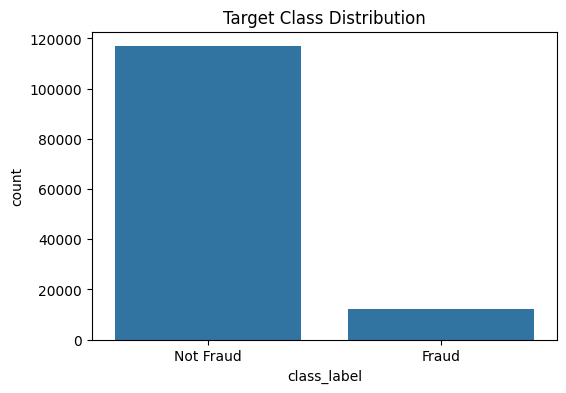

=== Class Imbalance ===


,Count,Percentage (%)
class,,
0,116878,90.500674
1,12268,9.499326


=== Bivariate Analysis ===


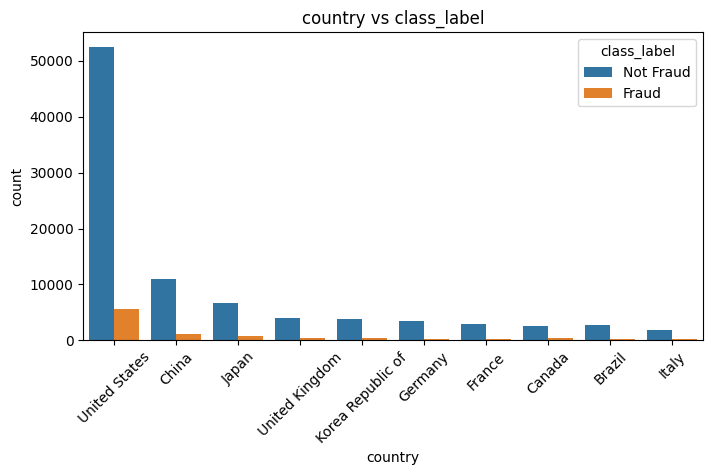

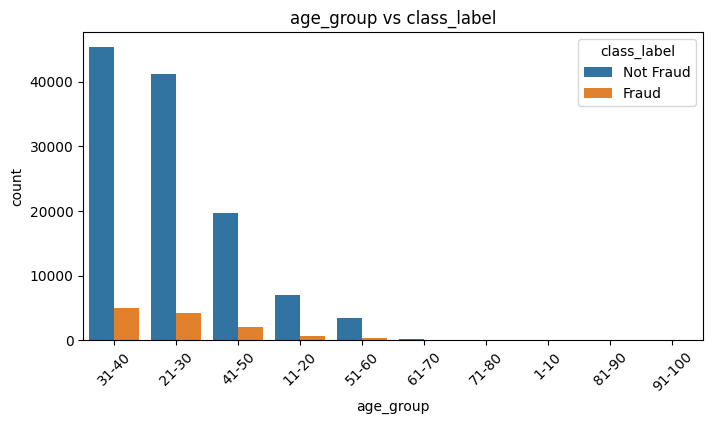

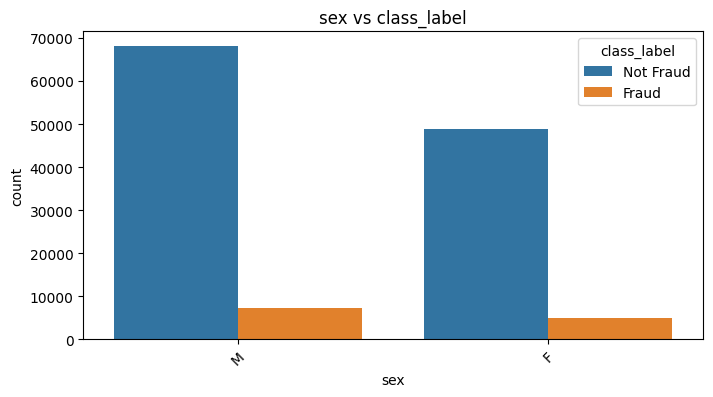

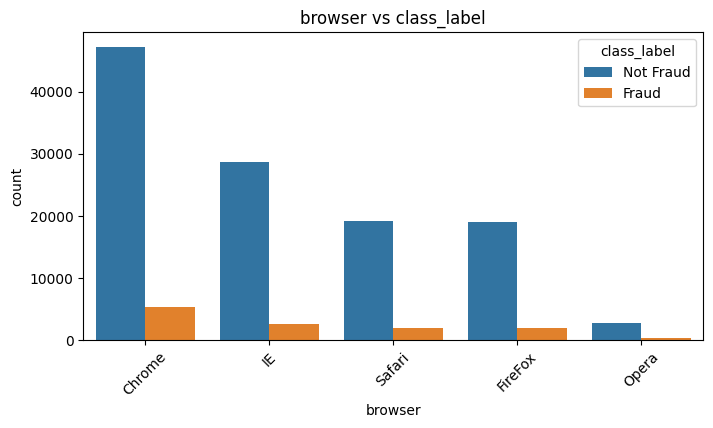

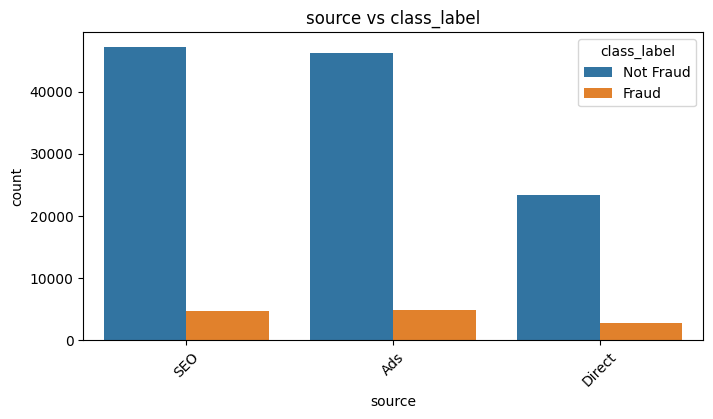

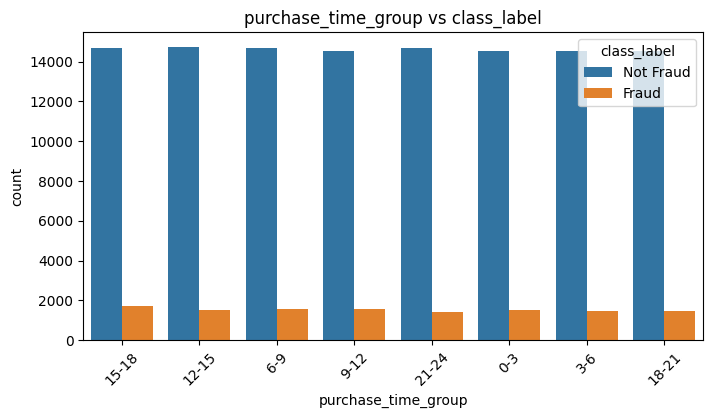

=== Multivariate Analysis (Country vs Age for Fraud) ===


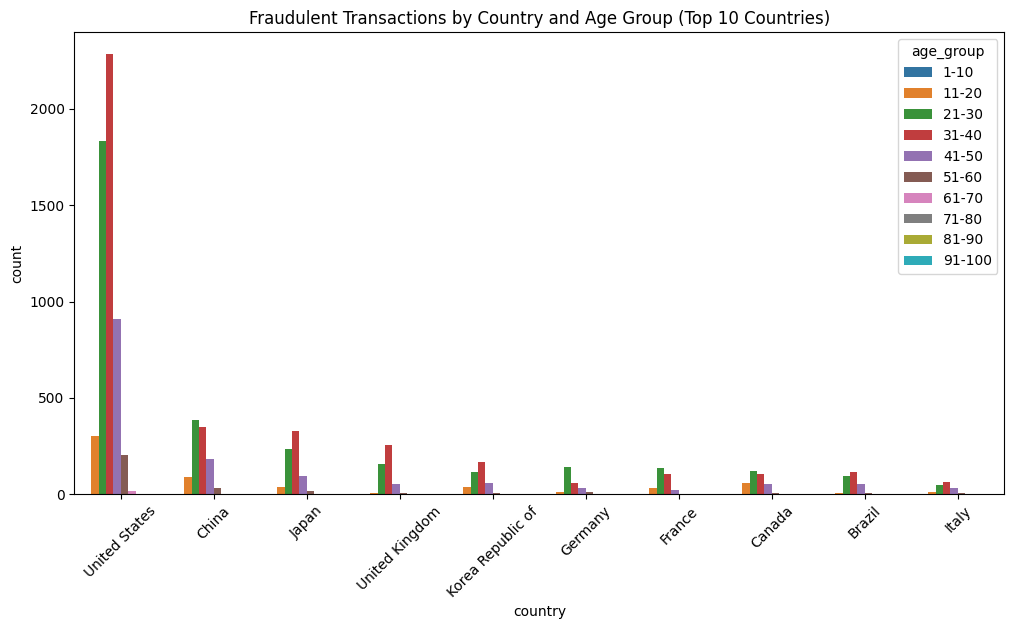

In [6]:
# Assuming df_clean has country column and target is 'is_fraud'
eda = ImportantFeaturesEDA(pdf_clean, target='class')
eda.run_all()


In [7]:
pdf_clean.to_csv('../data/cleaned_data.csv', index=False)